# Sequence specificity in DNA binding, worked through StatesAndRates

Every feature of the package, applied to the kinetic model of
Marklund *et al.*, *Science* **375**, 442–445 (2022), *Sequence
specificity in DNA binding is mainly governed by association*.

That paper describes how the *lac* repressor recognizes an operator
through a nonspecific testing intermediate, and derives the coupling
between the macroscopic association and dissociation rates that follows
(its Eq. 1). This is exactly the situation the package is built for: a
graph of states whose middle state no experiment resolves.

Every number below is either quoted from the paper's main text or read
off one of its figures, with the provenance given where it is
introduced. Rates are per second and free energies in kcal/mol,
converted to $k_\mathrm{B}T$ where the paper uses those units.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optimistix as optx

import statesandrates as sr

KT = sr.thermal_energy()  # kcal/mol at 298.15 K, for conversion to k_B T
COLOR = {"Osym": "tab:orange", "O1": "tab:red", "O2": "tab:green"}
LABEL = {"Osym": r"$O_\mathrm{sym}$", "O1": "$O_1$", "O2": "$O_2$"}
plt.rcParams.update(
    {
        "figure.figsize": (5, 3.2),
        "figure.dpi": 130,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

# Figures the slide deck includes, so the model is built and plotted in
# exactly one place. docs/presentation.tex reads these by name.
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)


def save(figure, name):
    """Write one figure for docs/presentation.tex to include."""
    figure.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")
    print(f"wrote figures/{name}.pdf")

## 1. The three-state model

Figure 1A of the paper: a repressor **searching** the genome makes a
nonspecific encounter with the operator, entering a **testing** state
from which it either recognizes the site and becomes specifically
**bound**, or escapes back into the search.

| transition | rate | meaning |
| --- | --- | --- |
| searching → testing | $k_\mathrm{on,max}$ | encounter with the target |
| testing → searching | $k_\mathrm{off,M}$ | escape from the encounter |
| testing → bound | $k_\mathrm{on,\mu}$ | recognition |
| bound → testing | $k_\mathrm{off,\mu}$ | microscopic dissociation |

The probability that an encounter ends in recognition is
$p_\mathrm{tot} = k_\mathrm{on,\mu} / (k_\mathrm{on,\mu} +
k_\mathrm{off,M})$, and the paper's Eq. 1 states that the macroscopic
rates obey
$k_\mathrm{a} = k_\mathrm{on,max} - (k_\mathrm{on,max} /
k_\mathrm{off,\mu})\,k_\mathrm{d}$,
which is to say $k_\mathrm{a} = k_\mathrm{on,max}\,p_\mathrm{tot}$ and
$k_\mathrm{d} = k_\mathrm{off,\mu}(1 - p_\mathrm{tot})$.

That table is the mechanism, and `Scheme` is how to write it down: states joined by *named* rates, with no values attached. It holds no
numbers, so none of the analyses below will accept it by mistake; giving it a value for each name returns an ordinary `Graph`.

In [2]:
MARKLUND = sr.Scheme(
    {
        ("searching", "testing"): "k_on_max",
        ("testing", "searching"): "k_off_M",
        ("testing", "bound"): "k_on_mu",
        ("bound", "testing"): "k_off_mu",
    },
    latex={
        "k_on_max": r"$k_\mathrm{on,max}$",
        "k_off_M": r"$k_\mathrm{off,M}$",
        "k_on_mu": r"$k_\mathrm{on,\mu}$",
        "k_off_mu": r"$k_\mathrm{off,\mu}$",
    },
)
# The spring layout is deterministic but arbitrary; placing the states by
# hand makes the chain read left to right, as in the paper's figures.
LAYOUT = {"searching": (0.0, 0.0), "testing": (1.0, 0.0), "bound": (2.0, 0.0)}

print(MARKLUND, "\nrates to supply:", MARKLUND.names)

o1 = MARKLUND.graph(
    {
        "k_on_max": 4.4e-3,
        "k_off_M": 100.0,
        "k_on_mu": 114.6,
        "k_off_mu": 6.0e-3,
    }
)
SEARCHING, TESTING, BOUND = (o1.index(state) for state in o1.states)

print(o1, "\ndetailed balanced:", sr.is_detailed_balanced(o1))
for source, target in o1.edges:
    rate = o1.rates[o1.index(source), o1.index(target)]
    print(f"  {source:>9} -> {target:<9} {rate:9.4g} /s")

# Nothing imposed that. A chain has no cycle, so there is none to carry a
# net flux and none for cycle_affinity to measure.
print(f"\nlargest net flux: {float(jnp.abs(sr.fluxes(o1)).max()):.1e}")
try:
    sr.cycle_affinity(o1, list(o1.states))
except ValueError as absent:
    print("cycle_affinity:", absent)

Scheme(states=('searching', 'testing', 'bound'), transitions=4) 
rates to supply: ('k_off_M', 'k_off_mu', 'k_on_max', 'k_on_mu')
Graph(states=('searching', 'testing', 'bound'), transitions=4) 
detailed balanced: True
  searching -> testing      0.0044 /s
    testing -> searching       100 /s
    testing -> bound         114.6 /s
      bound -> testing       0.006 /s


W0910 15:54:08.497765 4640839 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.



largest net flux: 4.3e-19
cycle_affinity: no transition from 'bound' to 'searching'


wrote figures/scheme.pdf


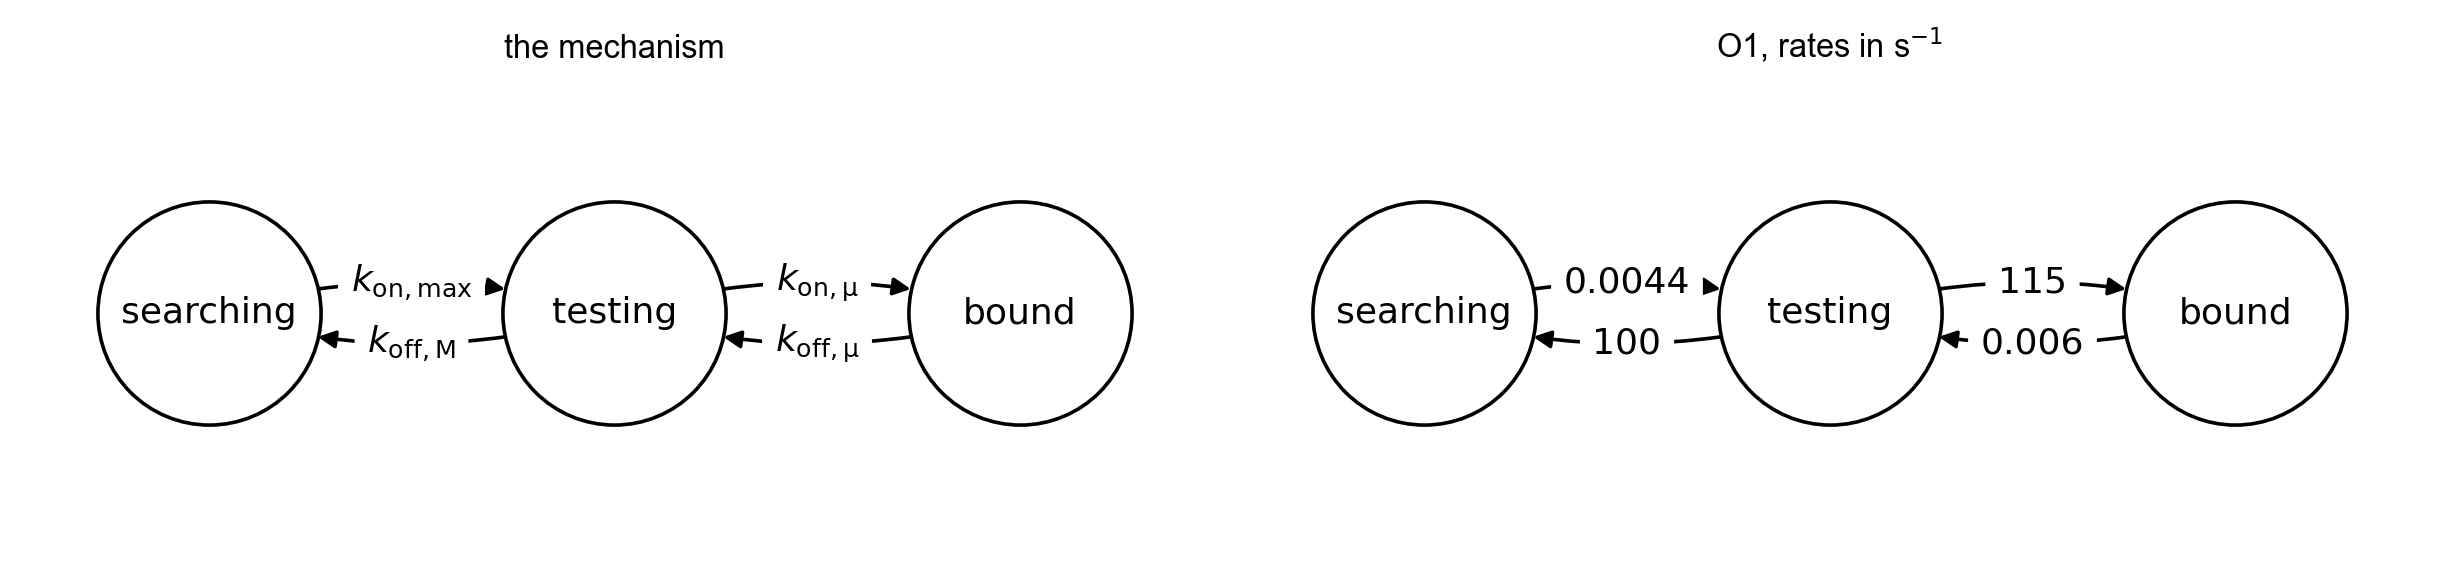

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 2.3))
layout = sr.state_diagram(MARKLUND, LAYOUT, ax=axes[0])
sr.state_diagram(o1, layout, ax=axes[1])
for ax, title in zip(axes, ("the mechanism", "O1, rates in s$^{-1}$")):
    ax.set_title(title, fontsize=9)
fig.tight_layout()
save(fig, "scheme")
plt.show()

A chain has no cycles, so any four positive rates are thermodynamically
consistent and `is_detailed_balanced` is `True`. That matters, because
it is what lets these rates be read as a free energy landscape below.

## 2. Four *lac* operators

Two of the four microscopic rates are shared by every operator:

* $k_\mathrm{on,max} = 4.4\times10^{-3}\ \mathrm{s^{-1}}$ per repressor
  per cell volume, the $k_\mathrm{d} \to 0$ intercept of the
  $k_\mathrm{a}$ lines in Fig. 3B;
* $k_\mathrm{off,M} = 100\ \mathrm{s^{-1}}$, a 10 ms encounter. Eq. 1
  does not contain it — only the ratio
  $k_\mathrm{on,\mu}/k_\mathrm{off,M}$ enters, through
  $p_\mathrm{tot}$ — and §5 confirms the macroscopic rates are
  insensitive to it. This value puts the testing state
  $\ln(k_\mathrm{off,M}/k_\mathrm{on,max}) = 10\ k_\mathrm{B}T$ above
  the free state, matching Fig. 3D.

Per operator, the paper reports $k_\mathrm{off,\mu} \approx
6\times10^{-3}\ \mathrm{s^{-1}}$ for $O_\mathrm{sym}$, $O_1$ and $O_2$
(Fig. 3C). The fourth operator it measures, $O_3$, is left out here: its
$k_\mathrm{d}$ is too uncertain to place (68% CI −0.08 to 0.24 s⁻¹), so
the paper draws no $k_\mathrm{off,\mu}$ line for it either. Equilibrium
constants come from
$O_1$ in Fig. 3B, $K_\mathrm{D} = k_\mathrm{d}/k_\mathrm{a} =
2.8/2.35$ per cell volume, scaled by the ratios quoted in the text:
$K_\mathrm{D}(O_2)$ exceeds $K_\mathrm{D}(O_1)$ by a factor of 4 and
$K_\mathrm{D}(O_\mathrm{sym})$ by a factor of 20.

Inverting $K_\mathrm{D} = k_\mathrm{d}/k_\mathrm{a}$ with Eq. 1 gives
each recognition probability,
$p_\mathrm{tot} = k_\mathrm{off,\mu} / (k_\mathrm{off,\mu} +
K_\mathrm{D}\,k_\mathrm{on,max})$.

That formula is the last time $p_\mathrm{tot}$ has to be written down.
Once the graph exists the same number is an **absorption probability** —
the chance that a repressor in the testing state reaches the operator
before it gets back to solution — and `absorption_probabilities` returns
it as a linear solve, agreeing with the closed form to the last bit.

Eq. 1 is then two statements about that one number. An encounter ends in
recognition with probability $p_\mathrm{tot}$, so
$k_\mathrm{a} = k_\mathrm{on,max}\,p_\mathrm{tot}$; and a repressor
that leaves the well lands in the testing state and escapes from there
with probability $1 - p_\mathrm{tot}$, so
$k_\mathrm{d} = k_\mathrm{off,\mu}(1 - p_\mathrm{tot})$. Both halves
of the paper's central result are consequences of one absorption
probability, and §5 measures how far each sits from the passage rate the
graph actually gives.

In [4]:
KON_MAX, KOFF_M = 4.4e-3, 100.0
DISSOCIATION = {"Osym": 1.19 / 5, "O1": 1.19, "O2": 1.19 * 4}
MICRO_OFF = {"Osym": 6e-3, "O1": 6e-3, "O2": 6e-3}


def operator(dissociation: float, k_off_mu: float) -> sr.Graph:
    """Three-state graph for one operator sequence."""
    p_tot = k_off_mu / (k_off_mu + dissociation * KON_MAX)
    return MARKLUND.graph(
        {
            "k_on_max": KON_MAX,
            "k_off_M": KOFF_M,
            "k_on_mu": KOFF_M * p_tot / (1 - p_tot),
            "k_off_mu": k_off_mu,
        }
    )


operators = {
    name: operator(DISSOCIATION[name], MICRO_OFF[name])
    for name in DISSOCIATION
}


def recognition_probability(each: sr.Graph) -> float:
    """Marklund's p_tot, read off the graph rather than the formula.

    The chance that the testing state reaches bound before it gets back
    to searching, which is what an absorption probability is.
    """
    reached = sr.absorption_probabilities(each, ["searching", "bound"])
    return float(reached[TESTING, BOUND])


print(
    f"{'':5} {'p_tot':>7} {'from the formula':>17} {'k_on,mu':>10}"
    f" {'k_off,mu':>10}"
)
for name, each in operators.items():
    k_on_mu = float(each.rates[TESTING, BOUND])
    print(
        f"{name:5} {recognition_probability(each):7.3f}"
        f" {k_on_mu / (k_on_mu + KOFF_M):17.3f}"
        f" {k_on_mu:7.1f} /s {MICRO_OFF[name]:7.3f} /s"
    )

        p_tot  from the formula    k_on,mu   k_off,mu


Osym    0.851             0.851   573.0 /s   0.006 /s
O1      0.534             0.534   114.6 /s   0.006 /s
O2      0.223             0.223    28.6 /s   0.006 /s


### An aside that matters: which concentration is this?

Association is bimolecular — a protein and a site have to find each other —
but every rate in a `Graph` is a *number*, not a function of a
concentration. The package only does first-order kinetics. So a bimolecular
step has to enter as a **pseudo-first-order** rate, with the concentration
folded in:

$$k_\mathrm{on,max}\;[\mathrm{s^{-1}}] \;=\;
  k_\mathrm{on}^{(2)}\;[\mathrm{M^{-1}s^{-1}}]\times[\mathrm{TF}] .$$

That is what Marklund's $k_\mathrm{on,max} = 4.4\times10^{-3}\
\mathrm{s^{-1}}$ already is: a rate quoted *per repressor per cell volume*.
So **these plots are not at a 1 M standard state, and not at an arbitrary
one either** — they are at one LacI per *E. coli* volume, about 1.7 nM. The
`searching` state is not "free protein" as a species; it is "this site is
unoccupied", and $p_\mathrm{searching}$ is the probability of that.

**This is why the wells in §4 are only a few $k_\mathrm{B}T$ deep.** The
drawn depths are $-0.85$, $+0.10$ and $+0.92$ kcal/mol for
$O_\mathrm{sym}$, $O_1$, $O_2$ — they are $\Delta G$ at 1.7 nM, not
$\Delta G^\circ$. Converting needs
$RT\ln(c^\circ/[\mathrm{TF}]) = 11.98\ \mathrm{kcal/mol} = 20.2\
k_\mathrm{B}T$, which is an order of magnitude larger than the features
being plotted. Adding it back gives $\Delta G^\circ = -12.8$, $-11.9$,
$-11.1$ kcal/mol, i.e. $K_d = 0.4$, $2.0$, $7.9$ nM — the familiar LacI
operator affinities. So the landscape is right, but reading a well depth as
a binding free energy would be wrong by 12 kcal/mol.

**What moves with concentration and what does not:**

| scales with $[\mathrm{TF}]$ | independent of it |
| --- | --- |
| occupancies $\pi$, and every free energy referenced to `searching` | $k_\mathrm{off,\mu}$, $k_\mathrm{off,M}$, $p_\mathrm{tot}$ |
| $k_\mathrm{a}$, and the barrier *into* the testing state | $k_\mathrm{d}$, and the barrier *out of* the bound state |
| the relaxation rate $k_\mathrm{a}+k_\mathrm{d}$, so §6's time course | the bound dwell time, and all of §5's dissociation-side algebra |

That asymmetry is the practical reason $k_\mathrm{d}$ transfers between
experiments and $k_\mathrm{a}$ does not.

**Changing the concentration is a multiplication**, which is exactly what
§11's flow cell does: `log_rates.at[SEARCHING, TESTING].add(log(ligand))`
scales the association rate by a time-dependent ligand factor. That is the
one place in this notebook where the concentration is explicit.

**What this framework cannot do.** Pseudo-first-order is exact only when the
free pool is *buffered* — $[\mathrm{TF}]\gg[\text{sites}]$, so binding does
not deplete it. A genuine second-order simulation, where the association
propensity responds to how many molecules are already bound, is outside the
package: the rates are constants. In particular, `simulate(graph,
{"searching": 200}, ...)` below means **200 independent copies of the
one-site system**, not 200 molecules competing for one site — which is what
`simulate`'s "molecules never interact" is telling you. Titration,
competition and depletion all need a bimolecular simulator.

## 3. Equilibrium populations and free energies

The stationary distribution follows from the rates alone, and the free
energies are $-RT\ln\pi$. Referenced to the searching state they are the
levels drawn in Fig. 3D: $O_\mathrm{sym}$ sits below the free state and
$O_2$ about 1.6 $k_\mathrm{B}T$ above it. The testing state is never
more than one part in $10^4$ of the population, which is why no
experiment sees it.

In [5]:
print(
    f"{'':5} {'pi_search':>10} {'pi_testing':>11} {'pi_bound':>9}"
    f" {'dG_bound/kT':>12} {'K_D':>8}"
)
for name, each in operators.items():
    pi = sr.equilibrium(each)
    energies = sr.free_energies(each, reference="searching") / KT
    print(
        f"{name:5} {pi[SEARCHING]:10.4f} {pi[TESTING]:11.2e}"
        f" {pi[BOUND]:9.4f} {energies[BOUND]:12.2f}"
        f" {DISSOCIATION[name]:8.3f}"
    )

# free_energies is -RT log of the stationary distribution, nothing more
assert np.allclose(sr.free_energies(o1), -KT * sr.log_equilibrium(o1))

       pi_search  pi_testing  pi_bound  dG_bound/kT      K_D
Osym      0.1922    8.46e-06    0.8077        -1.44    0.238
O1        0.5434    2.39e-05    0.4566         0.17    1.190
O2        0.8264    3.64e-05    0.1736         1.56    4.760


## 4. The free energy landscape

`barrier_energies` turns each rate constant into a barrier,
$\Delta G^\ddagger_{ij} = G_i - RT\ln(k_{ij}/k_0)$, which is
self-consistent from either direction of a transition because the graph
is detailed balanced. The prefactor $k_0$ is the rate of a barrierless
step; it shifts every barrier by $RT\ln k_0$ and so is exactly the
additive constant $c$ that the paper leaves undetermined in Fig. 3D.
Taking $k_0 = 10^6\ \mathrm{s^{-1}}$ reproduces its scale.

The activation energy out of the bound state is
$-RT\ln k_\mathrm{off,\mu} + c$, so operators that share a
$k_\mathrm{off,\mu}$ share that height and differ only in how deep the
bound well is — the paper's central observation. The rise into the
testing state appears here as a barrier because one prefactor is used
for every transition; the paper compresses that stretch of the
coordinate, since a diffusive search is not a single barrier crossing.

         bound     peak  from bound  from testing
Osym     -1.44    17.50       18.93          7.46
O1        0.17    19.11       18.93          9.07
O2        1.56    20.49       18.93         10.46


wrote figures/energy.pdf


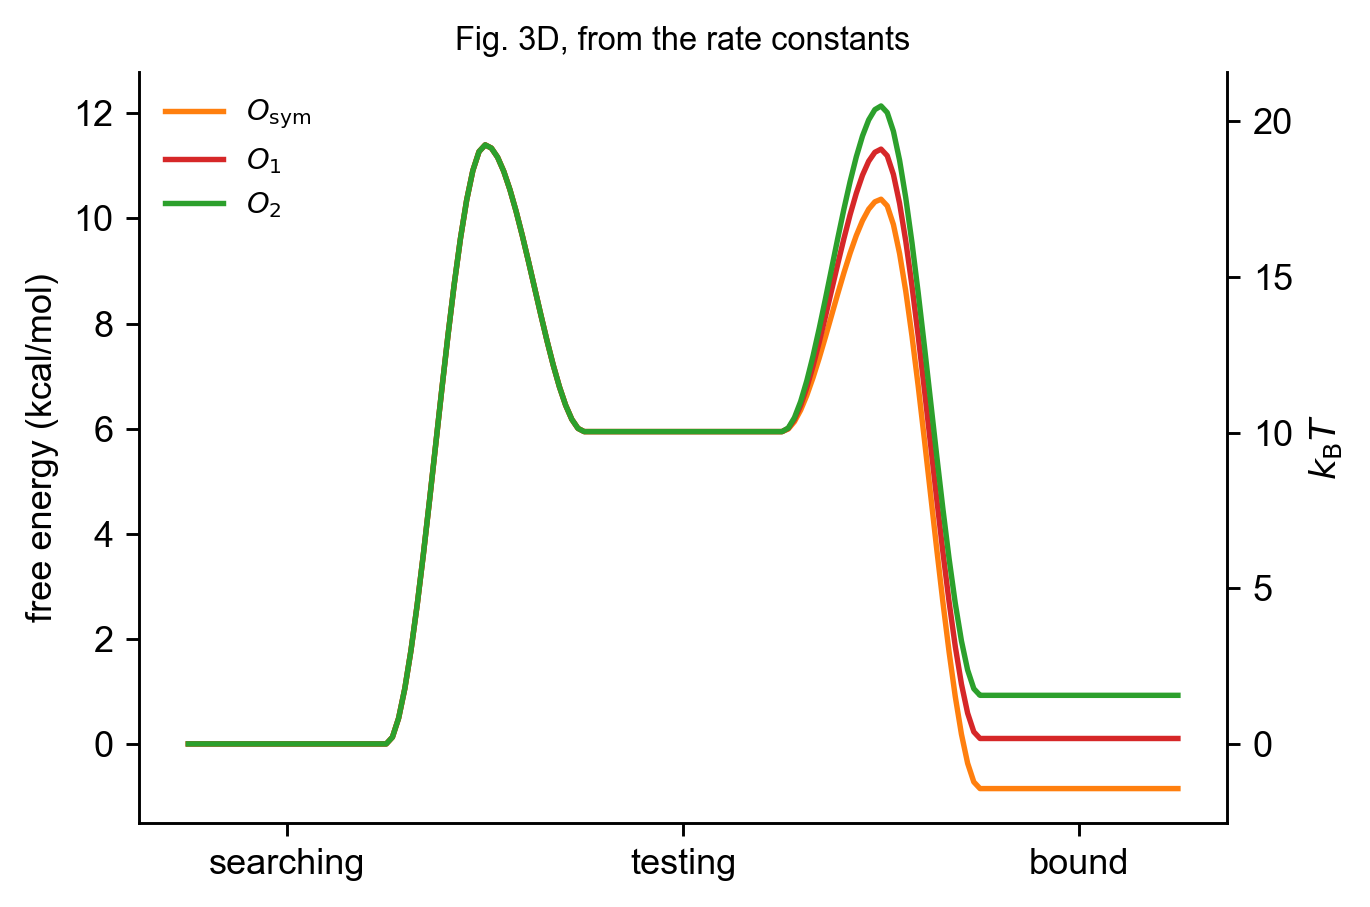

In [6]:
fig, ax = plt.subplots(figsize=(5.4, 3.6))
for name, each in operators.items():
    sr.energy_diagram(
        each,
        reference="searching",
        prefactor=1e6,
        ax=ax,
        color=COLOR[name],
        label=LABEL[name],
    )
ax.legend(frameon=False, loc="upper left", fontsize=8)
ax.set_title("Fig. 3D, from the rate constants", fontsize=9)
right = ax.secondary_yaxis(
    "right", functions=(lambda e: e / KT, lambda e: e * KT)
)
right.set_ylabel(r"$k_\mathrm{B}T$")

print(
    f"{'':5} {'bound':>8} {'peak':>8} {'from bound':>11}"
    f" {'from testing':>13}"
)
for name, each in operators.items():
    energies = sr.free_energies(each, reference="searching") / KT
    peaks = (
        sr.barrier_energies(each, reference="searching", prefactor=1e6) / KT
    )
    print(
        f"{name:5} {energies[BOUND]:8.2f} {peaks[TESTING, BOUND]:8.2f}"
        f" {peaks[TESTING, BOUND] - energies[BOUND]:11.2f}"
        f" {peaks[TESTING, BOUND] - energies[TESTING]:13.2f}"
    )
fig.tight_layout()
save(fig, "energy")

The last two columns are the same peak, measured from either side of
itself, and only one of them is constant. From the bound state the
activation energy is $18.9\ k_\mathrm{B}T$ for all three, because they
share a $k_\mathrm{off,\mu}$ — the paper's conclusion in a line. From
the testing plateau it spans $3\ k_\mathrm{B}T$, and that is what makes
one operator more specific than another.

## 5. What an experiment resolves: macroscopic rates

The testing state lasts milliseconds and is invisible, so a measurement
reports two rates rather than four. Which two depends on what it lumps
together, and the package offers both reductions: `passage_rates`
inverts mean first passage times, giving the rate a mean dwell time
reports, while `coarse_grain` averages rates over the local equilibrium,
matching equilibrium populations and fluxes.

Three lumpings of the same graph give three different pairs of rates:

* leaving the testing state as a macrostate of its own makes the
  reduction the *pairwise* first passage rate between searching and
  bound. That is the paper's definition, and it reproduces Eq. 1
  exactly. `coarse_grain` reports zero here, correctly: it matches the
  flux across the boundary between two macrostates, and there is no
  direct searching → bound transition to carry one;
* lumping the testing state with the search gives $k_\mathrm{a}$, but a
  dissociation rate of $k_\mathrm{off,\mu}$, since escaping to the
  testing state already counts as having left;
* lumping it with the bound state gives $k_\mathrm{d}$, but an
  association rate of $k_\mathrm{on,max}$, since every encounter counts
  as having arrived.

In [7]:
osym = operators["Osym"]
p_tot = recognition_probability(osym)
k_a, k_d = KON_MAX * p_tot, MICRO_OFF["Osym"] * (1 - p_tot)
print(
    f"Eq. 1     k_a={k_a:.4e}  k_d={k_d:.4e}"
    f"   k_on,max={KON_MAX:.4e}  k_off,mu={MICRO_OFF['Osym']:.4e}"
)

for groups in [
    {"searching": ["searching"], "bound": ["bound"]},
    {"apo": ["searching", "testing"], "bound": ["bound"]},
    {"searching": ["searching"], "occupied": ["testing", "bound"]},
]:
    forward, reverse = list(groups)
    print(
        f"\n{list(groups.values())}  lumpable={sr.is_lumpable(osym, groups)}"
    )
    for reduction in (sr.passage_rates, sr.coarse_grain):
        macro = reduction(osym, groups)
        i, j = macro.index(forward), macro.index(reverse)
        print(
            f"  {reduction.__name__:14} forward={macro.rates[i, j]:.4e}"
            f"  reverse={macro.rates[j, i]:.4e}"
        )

Eq. 1     k_a=3.7462e-03  k_d=8.9159e-04   k_on,max=4.4000e-03  k_off,mu=6.0000e-03

[['searching'], ['bound']]  lumpable=True


  passage_rates  forward=3.7461e-03  reverse=8.9158e-04
  coarse_grain   forward=0.0000e+00  reverse=0.0000e+00

[['searching', 'testing'], ['bound']]  lumpable=False


  passage_rates  forward=3.7463e-03  reverse=6.0000e-03
  coarse_grain   forward=2.5209e-02  reverse=6.0000e-03

[['searching'], ['testing', 'bound']]  lumpable=False
  passage_rates  forward=4.4000e-03  reverse=8.9158e-04
  coarse_grain   forward=4.4000e-03  reverse=1.0472e-03


`is_lumpable` reports that the last two partitions are not exactly
Markovian, and the flux reduction pays for it: lumping the testing state
with the search overestimates the association rate 6.7-fold, because it
counts every one of the rapid testing–bound recrossings as an
association event. First passage rates count only the crossings that
last.

The macroscopic rates should also be insensitive to $k_\mathrm{off,M}$,
which no experiment here constrains. Sweeping it over four decades at
fixed $p_\mathrm{tot}$ — `vmap` over a batch of log-rate matrices —
confirms that Eq. 1 holds wherever the encounter is brief compared with
the search.

In [8]:
def macroscopic(each: sr.Graph) -> jax.Array:
    """Pairwise first passage rates between searching and bound."""
    rate_on = 1 / sr.mean_first_passage_times(each, "bound")[SEARCHING]
    rate_off = 1 / sr.mean_first_passage_times(each, "searching")[BOUND]
    return jnp.stack([rate_on, rate_off])


batched = jax.jit(
    jax.vmap(lambda rates: macroscopic(osym.with_log_rates(rates)))
)
escape = np.logspace(0, 4, 5)
sweep = np.stack(
    [
        np.asarray(
            osym.log_rates.at[TESTING, SEARCHING]
            .set(np.log(rate))
            .at[TESTING, BOUND]
            .set(np.log(rate * p_tot / (1 - p_tot)))
        )
        for rate in escape
    ]
)
for rate, (rate_on, rate_off) in zip(escape, np.asarray(batched(sweep))):
    print(
        f"k_off,M={rate:8.0f} /s   k_a={rate_on:.4e}  k_d={rate_off:.4e}"
        f"   (Eq. 1: {k_a:.4e}, {k_d:.4e})"
    )

k_off,M=       1 /s   k_a=3.7437e-03  k_d=8.9079e-04   (Eq. 1: 3.7462e-03, 8.9159e-04)
k_off,M=      10 /s   k_a=3.7459e-03  k_d=8.9151e-04   (Eq. 1: 3.7462e-03, 8.9159e-04)
k_off,M=     100 /s   k_a=3.7461e-03  k_d=8.9158e-04   (Eq. 1: 3.7462e-03, 8.9159e-04)
k_off,M=    1000 /s   k_a=3.7462e-03  k_d=8.9159e-04   (Eq. 1: 3.7462e-03, 8.9159e-04)
k_off,M=   10000 /s   k_a=3.7462e-03  k_d=8.9159e-04   (Eq. 1: 3.7462e-03, 8.9159e-04)


### Where that passage time is actually spent

A passage time is a single number, so it cannot say *where* the time goes.
`mean_residence_times` returns the matrix it is the row sums of: entry
$(i,j)$ is the total time spent in $j$, over every visit, before the target
is reached. It is $-\mathbf{Q}_{\mathcal{FF}}^{-1}$ itself rather than
$-\mathbf{Q}_{\mathcal{FF}}^{-1}\mathbf{1}$.

That answers a question this notebook has been glossing over. The package
does **no symbolic algebra** — there is no closed-form solver in it, and
`passage_rates` is a linear solve. But splitting the passage time by state
recovers Eq. 1 analytically for this chain:

* the residence in **bound** before reaching searching is
  $1/[k_{\mathrm{off},\mu}(1-p_\mathrm{tot})] = 1/k_\mathrm{d}$ — Marklund's
  closed form, exactly, because the walker makes
  $1/(1-p_\mathrm{tot})$ visits to bound and each lasts
  $1/k_{\mathrm{off},\mu}$;
* the residence in **testing** is $1/k_\mathrm{off,M}$ — one lifetime of the
  intermediate, no matter how many times it is visited, since the
  $1/(1-p_\mathrm{tot})$ visits each last $1/(k_\mathrm{on,\mu} +
  k_\mathrm{off,M})$ and the two factors cancel.

So the passage time is $1/k_\mathrm{d} + 1/k_\mathrm{off,M}$, and
$1/\mathrm{MFPT}$ is Eq. 1 only when the intermediate is short-lived. With
$r = k_\mathrm{d}/k_\mathrm{off,M}$ the error is exactly $r/(1+r)$: about
$3\times10^{-5}$ for these operators, where the testing state lasts 10 ms,
but 10% for rates in which it lasts seconds. Dividing by $\varphi$ makes
the same point in reverse: the number of visits is $1/(1-p_\mathrm{tot})$,
which is the recapture count.

         in bound      1/k_d    ratio  in testing  1/k_off,M  visits
Osym      1121.59    1121.59   1.0000      0.0100     0.0100   6.730
O1         357.65     357.65   1.0000      0.0100     0.0100   2.146
O2         214.41     214.41   1.0000      0.0100     0.0100   1.286


wrote figures/residence.pdf


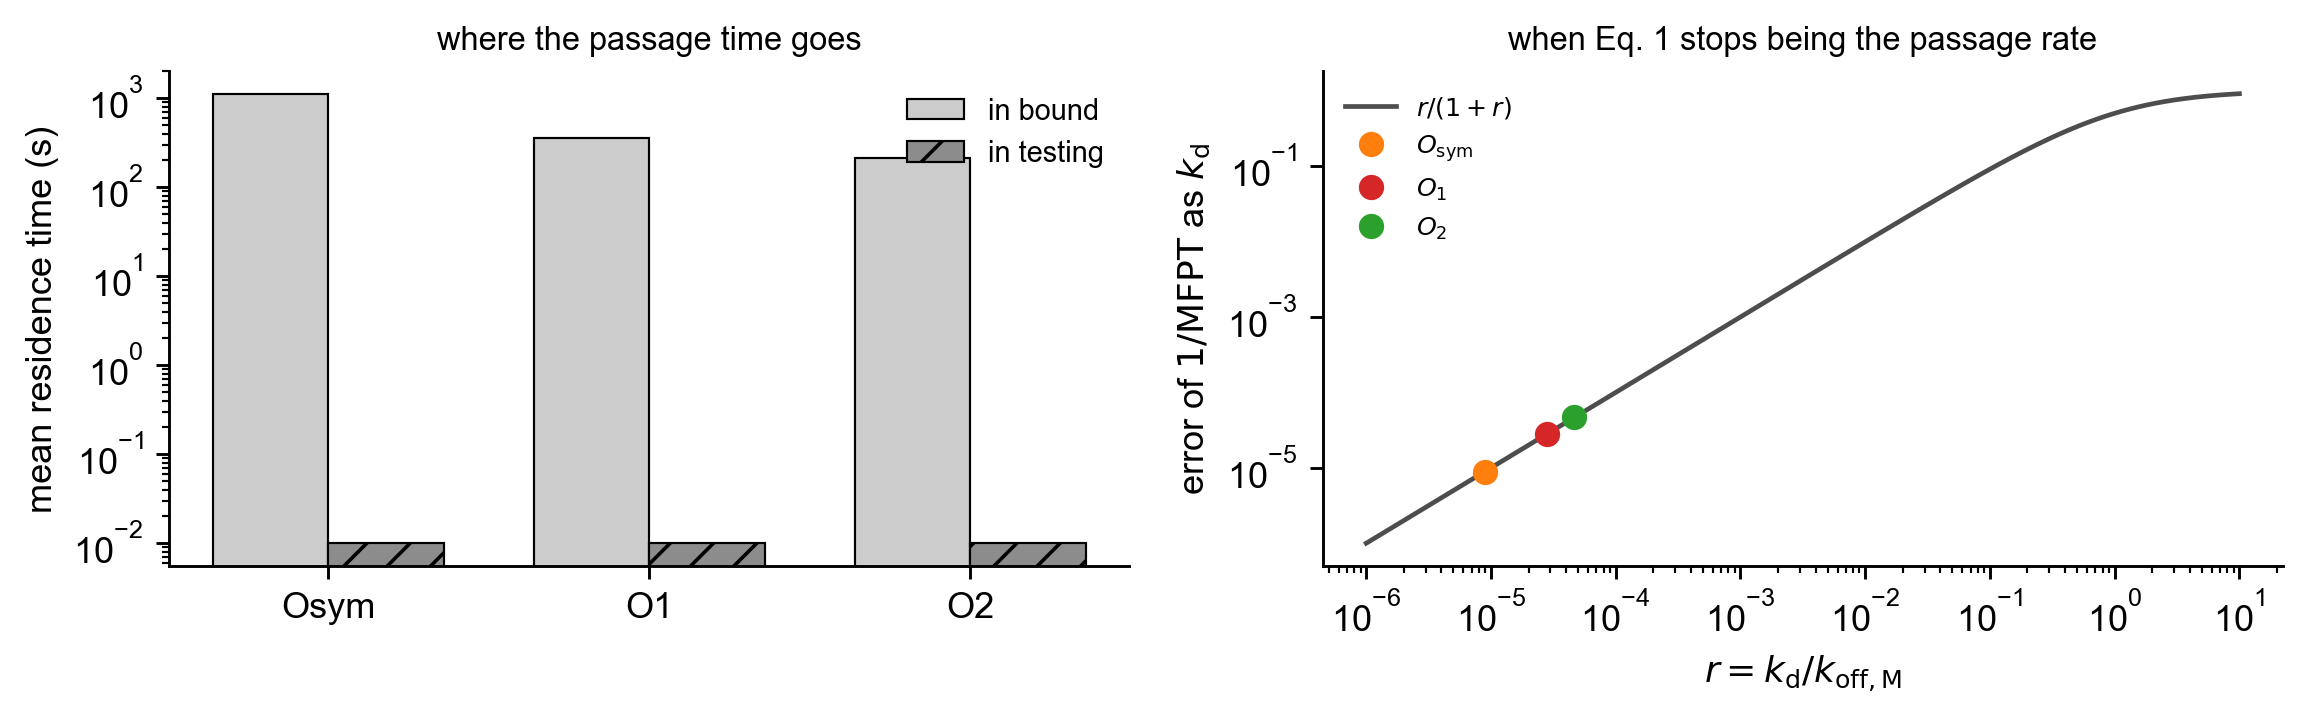

In [9]:
residence = {
    name: np.asarray(sr.mean_residence_times(each, "searching"))
    for name, each in operators.items()
}
print(
    f"{'':6}{'in bound':>11}{'1/k_d':>11}{'ratio':>9}"
    f"{'in testing':>12}{'1/k_off,M':>11}{'visits':>8}"
)
for name, each in operators.items():
    p_tot = recognition_probability(each)
    closed = 1 / (MICRO_OFF[name] * (1 - p_tot))
    in_bound = residence[name][BOUND, BOUND]
    in_testing = residence[name][BOUND, TESTING]
    exits = float(-np.asarray(each.generator())[BOUND, BOUND])
    print(
        f"{name:6}{in_bound:11.2f}{closed:11.2f}{in_bound / closed:9.4f}"
        f"{in_testing:12.4f}{1 / KOFF_M:11.4f}{in_bound * exits:8.3f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(9.0, 2.9))
width, offsets = 0.36, np.arange(len(operators))
for index, (state, shade, hatch) in enumerate(
    (("bound", "0.8", ""), ("testing", "0.55", "//"))
):
    axes[0].bar(
        offsets + (index - 0.5) * width,
        [
            residence[n][BOUND, each.index(state)]
            for n, each in operators.items()
        ],
        width,
        color=shade,
        edgecolor="black",
        linewidth=0.6,
        hatch=hatch,
        label=f"in {state}",
    )
axes[0].set(
    yscale="log",
    xticks=offsets,
    xticklabels=list(operators),
    ylabel="mean residence time (s)",
    title="where the passage time goes",
)
axes[0].title.set_size(9)
axes[0].legend(frameon=False, fontsize=8)

ratio = np.logspace(-6, 1, 200)
axes[1].plot(
    ratio, ratio / (1 + ratio), color="0.3", lw=1.3, label="$r/(1+r)$"
)
for name, each in operators.items():
    p_tot = recognition_probability(each)
    closed = MICRO_OFF[name] * (1 - p_tot)
    passage = float(
        np.asarray(sr.mean_first_passage_times(each, "searching"))[BOUND]
    )
    axes[1].plot(
        closed / KOFF_M,
        abs(1 / passage - closed) / closed,
        "o",
        color=COLOR[name],
        label=LABEL[name],
    )
axes[1].set(
    xscale="log",
    yscale="log",
    xlabel=r"$r = k_\mathrm{d}/k_\mathrm{off,M}$",
    ylabel=r"error of $1/\mathrm{MFPT}$ as $k_\mathrm{d}$",
    title="when Eq. 1 stops being the passage rate",
)
axes[1].title.set_size(9)
axes[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
save(fig, "residence")

## 6. The anticorrelation (Figs. 1B and 3B)

Eq. 1 is a straight line in $(k_\mathrm{d}, k_\mathrm{a})$ space at
fixed $k_\mathrm{off,\mu}$, traced out by $p_\mathrm{tot}$. Reducing the
graph over a sweep of $p_\mathrm{tot}$ recovers that line, with each
operator falling on the line belonging to its own
$k_\mathrm{off,\mu}$.

wrote figures/macro.pdf


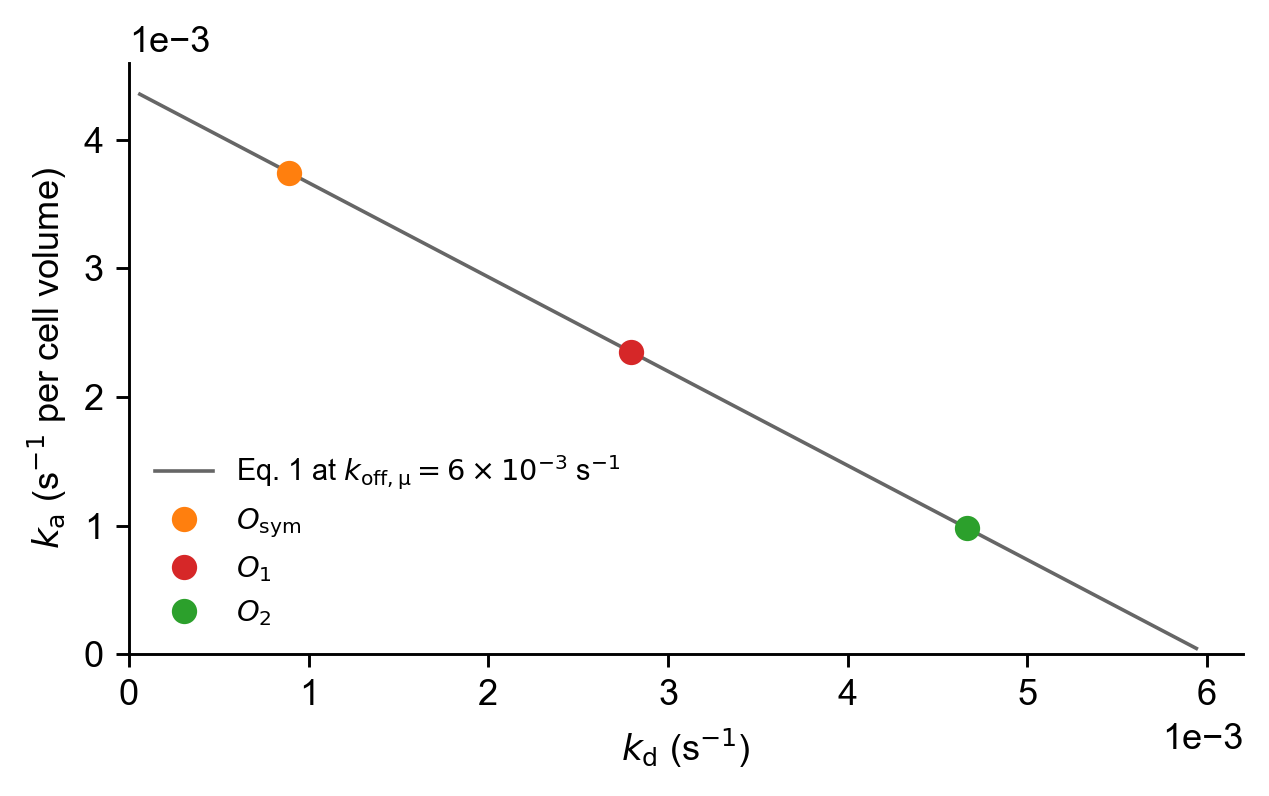

In [10]:
fig, ax = plt.subplots()
line = np.stack(
    [
        np.asarray(
            macroscopic(
                MARKLUND.graph(
                    {
                        "k_on_max": KON_MAX,
                        "k_off_M": KOFF_M,
                        "k_on_mu": KOFF_M * p / (1 - p),
                        "k_off_mu": 6e-3,
                    }
                )
            )
        )
        for p in np.linspace(0.01, 0.99, 60)
    ]
)
ax.plot(
    line[:, 1],
    line[:, 0],
    color="0.4",
    lw=1,
    label=r"Eq. 1 at $k_\mathrm{off,\mu} = 6\times10^{-3}$ s$^{-1}$",
)
for name, each in operators.items():
    observed = np.asarray(macroscopic(each))
    ax.plot(
        observed[1], observed[0], "o", color=COLOR[name], label=LABEL[name]
    )
ax.set(
    xlim=(0, 6.2e-3),
    ylim=(0, 4.6e-3),
    xlabel=r"$k_\mathrm{d}$ (s$^{-1}$)",
    ylabel=r"$k_\mathrm{a}$ (s$^{-1}$ per cell volume)",
)
ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
save(fig, "macro")

The three operators share their barrier out of the bound state, yet
their $k_\mathrm{d}$ spans fivefold along that line. This is not a
contradiction: crossing that barrier only reaches the testing state,
and from there the repressor either escapes, at $k_\mathrm{off,M}$, or
falls back in, at $k_\mathrm{on,\mu}$. Getting away therefore takes
$1/(1 - p_\mathrm{tot})$ crossings — 6.7 of them for $O_\mathrm{sym}$
against 1.3 for $O_2$ — which is exactly
$k_\mathrm{d} = k_\mathrm{off,\mu}(1 - p_\mathrm{tot})$. An activation
energy means nothing without the state it is measured from: from the
bound well the peak sits at one height for all three operators, from
the testing plateau it does not, and the gap between those two readings
is the binding free energy that separates them.

In [11]:
print(
    f"{'':6} {'from bound':>11} {'from testing':>13} {'p_tot':>7}"
    f" {'crossings':>10} {'k_off,mu':>9} {'k_d':>10}"
)
for name, each in operators.items():
    energies = sr.free_energies(each, reference="searching") / KT
    peaks = (
        sr.barrier_energies(each, reference="searching", prefactor=1e6) / KT
    )
    p_tot = recognition_probability(each)
    print(
        f"{name:6} {peaks[TESTING, BOUND] - energies[BOUND]:11.2f}"
        f" {peaks[TESTING, BOUND] - energies[TESTING]:13.2f}"
        f" {p_tot:7.3f} {1 / (1 - p_tot):10.1f}"
        f" {float(each.rates[BOUND, TESTING]):9.4f}"
        f" {float(macroscopic(each)[1]):10.3e}"
    )

# Both barriers out of the testing state, for one operator
energies = sr.free_energies(osym, reference="searching") / KT
peaks = sr.barrier_energies(osym, reference="searching", prefactor=1e6) / KT
away = float(peaks[SEARCHING, TESTING] - energies[TESTING])
back = float(peaks[TESTING, BOUND] - energies[TESTING])
print(
    f"\nOsym leaves the testing state over {away:.2f} kT to solution"
    f" or {back:.2f} kT back into the well;"
)
print(
    f"that {away - back:+.2f} kT difference is p_tot ="
    f" {1 / (1 + np.exp(-(away - back))):.3f}"
)

        from bound  from testing   p_tot  crossings  k_off,mu        k_d
Osym         18.93          7.46   0.851        6.7    0.0060  8.916e-04
O1           18.93          9.07   0.534        2.1    0.0060  2.796e-03
O2           18.93         10.46   0.223        1.3    0.0060  4.664e-03

Osym leaves the testing state over 9.21 kT to solution or 7.46 kT back into the well;
that +1.75 kT difference is p_tot = 0.851


## 7. Mutations change recognition or retention (Fig. 1D)

A mutation is a perturbation of the landscape, and the paper's two
microscopic parameters are two independent perturbations of it:

* **recognition** — raise the barrier to recognition *and* the bound
  state by the same amount. $k_\mathrm{on,\mu}$ falls,
  $k_\mathrm{off,\mu}$ is untouched, so $p_\mathrm{tot}$ drops at fixed
  microscopic dissociation.
* **retention** — raise the bound state alone. Every rate out of it
  speeds up, so $k_\mathrm{off,\mu}$ rises, while $p_\mathrm{tot}$
  depends only on rates out of the testing state and is unchanged.

Both are written in kcal/mol, both leave the graph thermodynamically
consistent, and `Mutation` objects add, so a double mutant is the sum of
two singles.

In [12]:
recognition = sr.Mutation(
    barriers={("testing", "bound"): 1.0},
    states={"bound": 1.0},
    name="recognition",
)
retention = sr.Mutation(states={"bound": 1.0}, name="retention")
print("shift in log rates per kcal/mol, times RT:")
print(" recognition\n", (recognition.log_shift(osym) * KT).round(2))
print(" retention\n", (retention.log_shift(osym) * KT).round(2))

for mutation in (recognition, retention, recognition + retention):
    mutant = osym.mutate(mutation)
    print(
        f"{mutation.name:24} p_tot={recognition_probability(mutant):.3f}"
        f"  k_off,mu={float(mutant.rates[BOUND, TESTING]):.4f}"
        f"  balanced={sr.is_detailed_balanced(mutant)}"
    )
assert np.allclose(
    osym.mutate(recognition + retention).log_rates,
    osym.mutate(recognition, retention).log_rates,
)

shift in log rates per kcal/mol, times RT:
 recognition
 [[ 0.  0.  0.]
 [ 0.  0. -1.]
 [ 1.  0.  1.]]
 retention
 [[0. 0. 0.]
 [0. 0. 0.]
 [1. 1. 1.]]
recognition              p_tot=0.514  k_off,mu=0.0060  balanced=True
retention                p_tot=0.851  k_off,mu=0.0324  balanced=True
recognition + retention  p_tot=0.514  k_off,mu=0.0324  balanced=True


Figure 1D asks what a library of mutants looks like when the two
perturbations vary to different extents. Because a mutation is an
additive shift of the log rates, a library is a single array of shifted
matrices and the reduction runs over all of it under `vmap`.

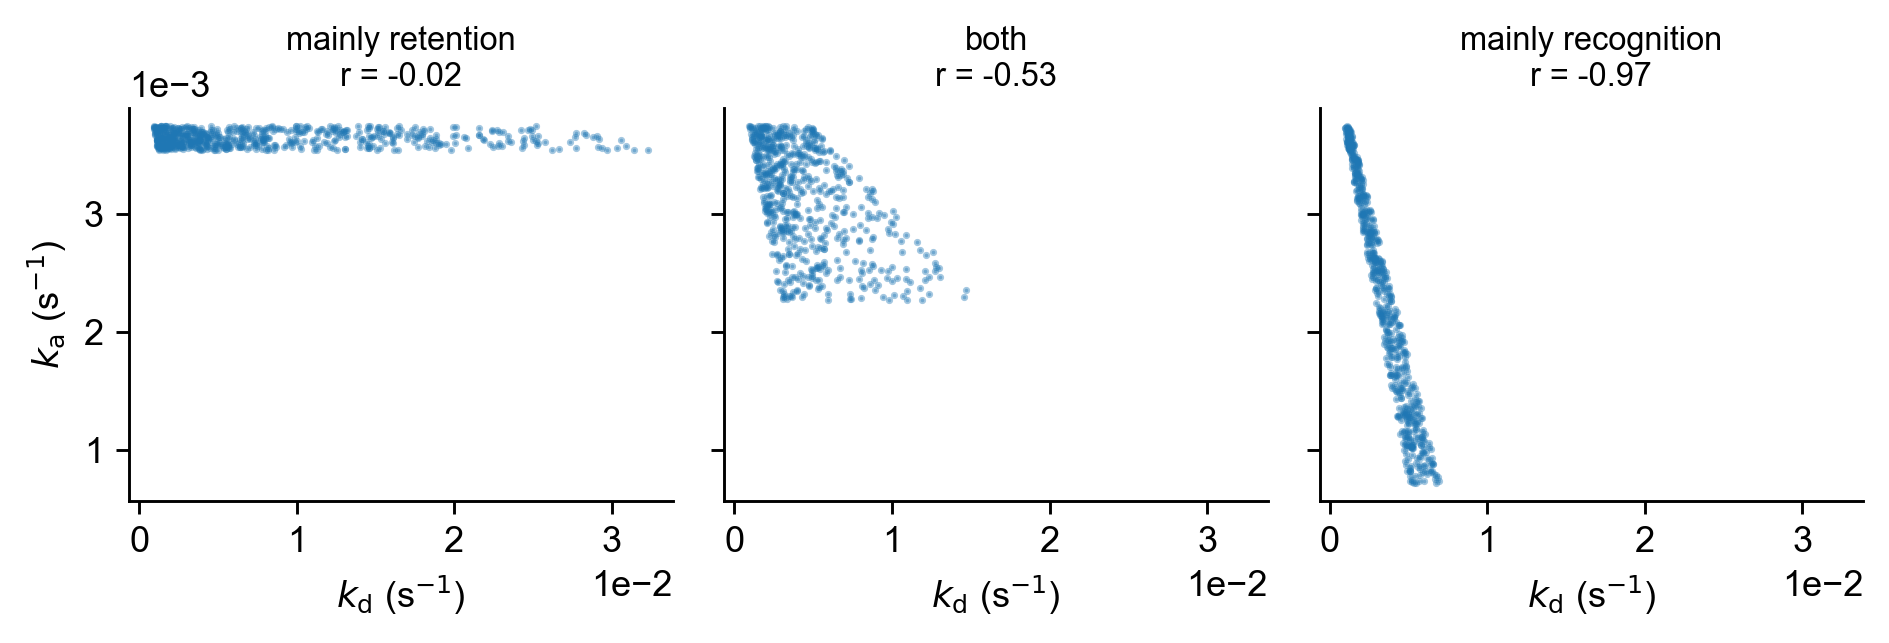

In [13]:
rng = np.random.default_rng(0)
shifts = np.stack([recognition.log_shift(osym), retention.log_shift(osym)])
scenarios = [
    ("mainly retention", (0.2, 2.0)),
    ("both", (1.0, 1.0)),
    ("mainly recognition", (2.0, 0.2)),
]

fig, axes = plt.subplots(1, 3, figsize=(7.5, 2.6), sharex=True, sharey=True)
for ax, (title, spread) in zip(axes, scenarios):
    amplitude = rng.uniform(0, 1, (600, 2)) * np.array(spread)
    library = osym.log_rates + jnp.einsum("mp,pij->mij", amplitude, shifts)
    rates = np.asarray(batched(library))
    ax.plot(rates[:, 1], rates[:, 0], ".", ms=2, alpha=0.4, color="tab:blue")
    ax.set(
        title=f"{title}\nr = {np.corrcoef(rates.T)[0, 1]:+.2f}",
        xlabel=r"$k_\mathrm{d}$ (s$^{-1}$)",
    )
    ax.ticklabel_format(axis="both", style="sci", scilimits=(0, 0))
    ax.title.set_size(9)
axes[0].set_ylabel(r"$k_\mathrm{a}$ (s$^{-1}$)")
fig.tight_layout()

Only when recognition varies more than retention does a library fall on
the anticorrelated line. That is the signature the paper looks for in
its microarray data, and finds.

## 8. The observable time course

`relaxation_times` gives the exponential phases of the master equation.
There are two: the millisecond equilibration of the testing state, and
the slow approach to binding equilibrium at $1/(k_\mathrm{a} +
k_\mathrm{d})$. Only the slow one is observable, which is why single
exponentials describe the association curves in Fig. 2B.

relaxation times (s): [2.15621504e+02 1.48600000e-03]
1/(k_a + k_d) = 215.6 s
wrote figures/relaxation.pdf


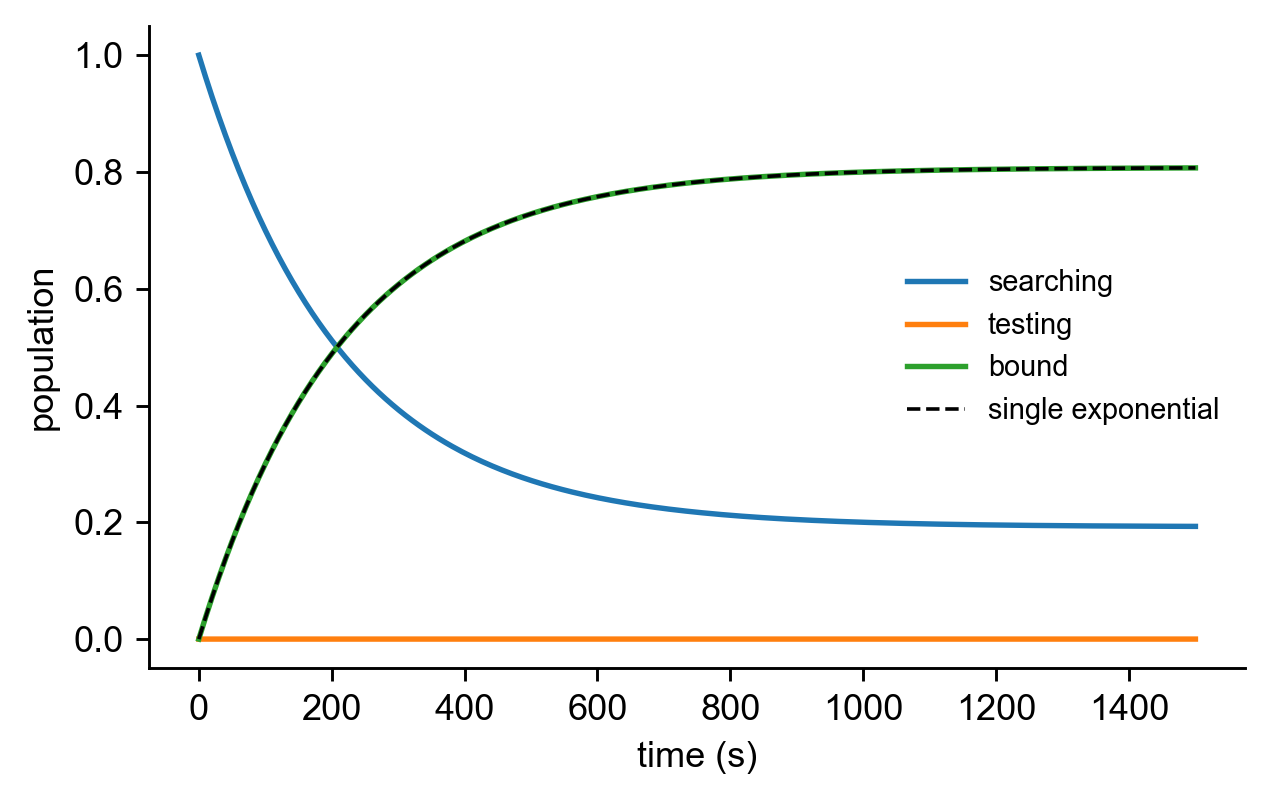

In [14]:
times = np.linspace(0, 1500, 300)
amounts = sr.propagate(osym, {"searching": 1.0}, times)
observed = np.asarray(macroscopic(osym))
single = observed[0] / observed.sum() * -np.expm1(-observed.sum() * times)

print("relaxation times (s):", np.asarray(sr.relaxation_times(osym)).round(6))
print(f"1/(k_a + k_d) = {1 / observed.sum():.1f} s")

fig, ax = plt.subplots()
for state, index in zip(osym.states, (SEARCHING, TESTING, BOUND)):
    ax.plot(times, amounts[:, index], label=state)
ax.plot(times, single, "k--", lw=1, label="single exponential")
ax.set(xlabel="time (s)", ylabel="population")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save(fig, "relaxation")

## 9. A flow cell with a finite exchange time

The microarray and single-molecule experiments flow protein in and then
wash it out, so $k_\mathrm{on,max}$ is proportional to a concentration
that changes with time. Constant rates no longer apply and `propagate`
cannot be used; `integrate` solves the same master equation with a
Diffrax stiff solver, taking the graph as a function of time.

Comparing a chamber that exchanges with a 200 s time constant against an
instantaneous step shows how much of a measured curve is exchange rather
than binding.

washed-out graph is reversible: False
wrote figures/washout.pdf


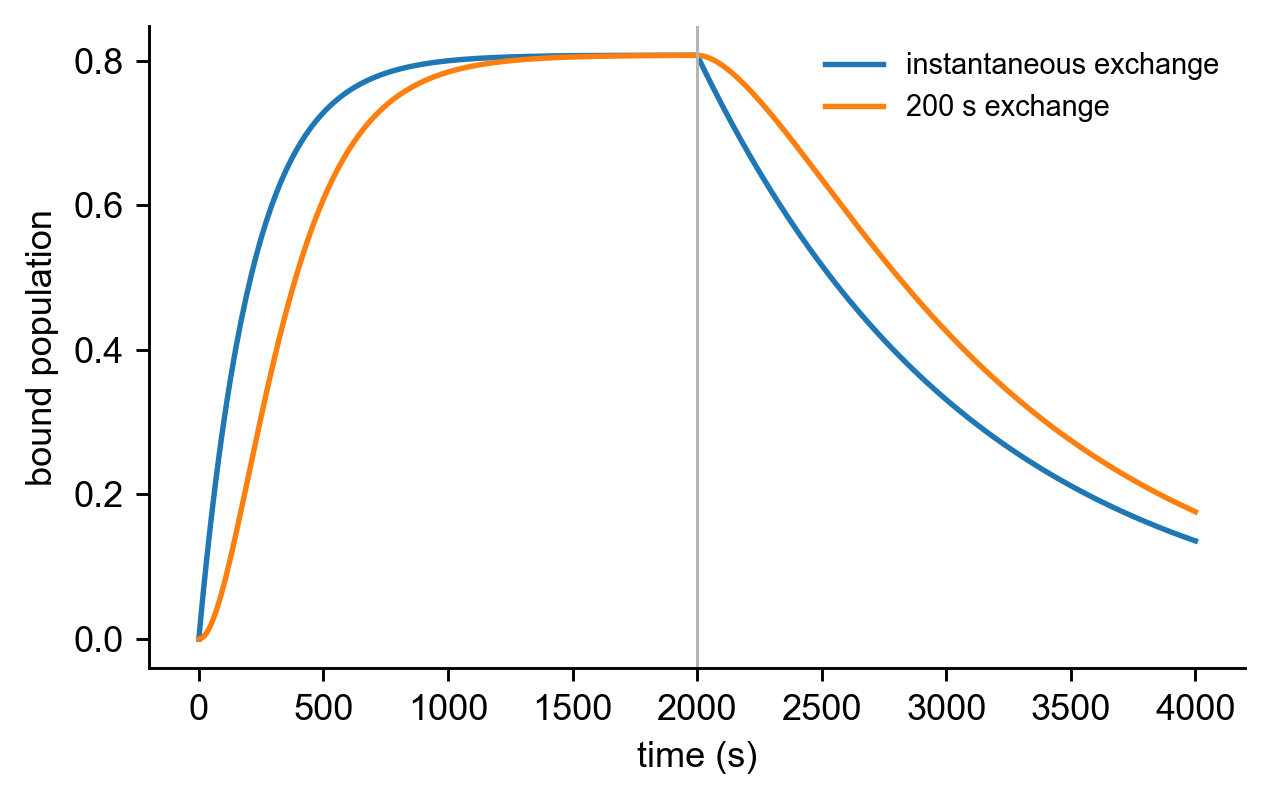

In [15]:
WASH, MIX = 2000.0, 200.0


def flowing(t: jax.Array) -> sr.Graph:
    """The graph at time t, with protein washed out after WASH."""
    ligand = jnp.where(
        t < WASH, -jnp.expm1(-t / MIX), jnp.exp(-(t - WASH) / MIX)
    )
    return osym.with_log_rates(
        osym.log_rates.at[SEARCHING, TESTING].add(jnp.log(ligand))
    )


times = np.linspace(0, 4000, 401)
mixed = sr.integrate(flowing, {"searching": 1.0}, times, rtol=1e-6, atol=1e-9)

# The ideal experiment: protein on at t = 0, gone at t = WASH
washed = osym.with_log_rates(
    osym.log_rates.at[SEARCHING, TESTING].set(-jnp.inf)
)
association = sr.propagate(osym, {"searching": 1.0}, times[times <= WASH])
dissociation = sr.propagate(
    washed, association[-1], times[times > WASH] - WASH
)
step = np.concatenate([association, dissociation])
print("washed-out graph is reversible:", sr.is_detailed_balanced(washed))

fig, ax = plt.subplots()
ax.plot(times, step[:, BOUND], label="instantaneous exchange")
ax.plot(times, mixed[:, BOUND], label=f"{MIX:.0f} s exchange")
ax.axvline(WASH, color="0.7", lw=0.8)
ax.set(xlabel="time (s)", ylabel="bound population")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save(fig, "washout")

With the protein removed there is no longer a reverse for every
transition, so `propagate` falls back to a matrix exponential on its
own; the resulting decay is exponential at exactly $k_\mathrm{d}$.

## 10. Single molecules

`simulate` runs the same graph as a Gillespie process. Figure 1C shows
individual traces, and the contrast between a strong and a weak operator
is the fraction of time spent bound, which is the equilibrium population
of the bound state. The brief spikes out of it are the recrossings that
separate $k_\mathrm{off,\mu}$ from $k_\mathrm{d}$.

wrote figures/gillespie.pdf


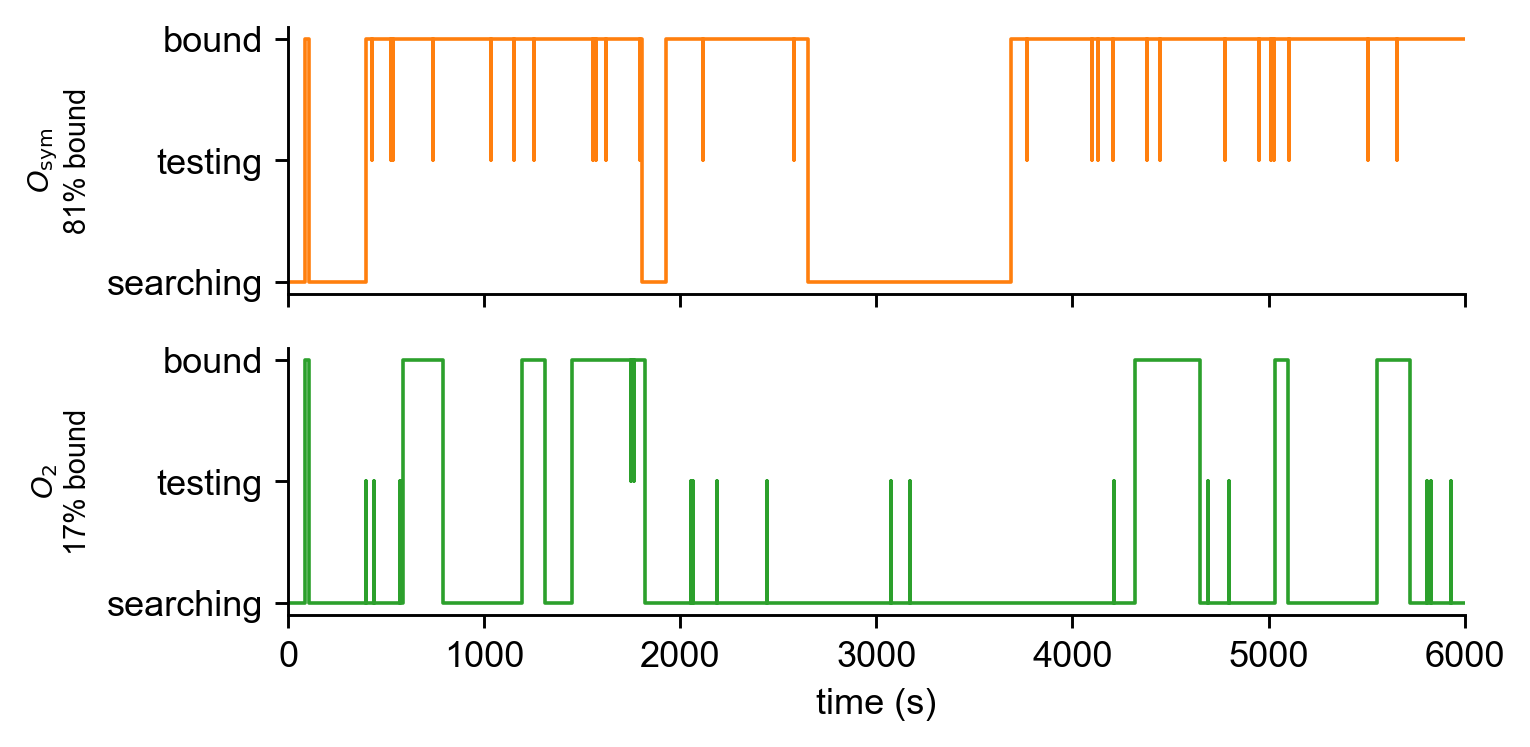

In [16]:
DURATION = 6000.0

fig, axes = plt.subplots(2, 1, figsize=(6, 3), sharex=True, sharey=True)
for ax, name in zip(axes, ("Osym", "O2")):
    trace = sr.simulate(operators[name], {"searching": 1}, DURATION, seed=3)
    when, visited = trace.path(0)
    inside = when <= DURATION
    ax.step(
        np.append(when[inside], DURATION),
        np.append(visited[inside], visited[inside][-1]),
        where="post",
        color=COLOR[name],
        lw=1,
    )
    bound = float(sr.equilibrium(operators[name])[BOUND])
    ax.set(
        xlim=(0, DURATION),
        yticks=range(3),
        yticklabels=osym.states,
        ylabel=f"{LABEL[name]}\n{bound:.0%} bound",
    )
    ax.yaxis.label.set_size(8)
axes[-1].set_xlabel("time (s)")
fig.tight_layout()
save(fig, "gillespie")

The dwell time in the bound state is where the microscopic and
macroscopic rates part company. A molecule that escapes to the testing
state usually comes straight back, so the observable dwell is
$1/k_\mathrm{d}$, longer than $1/k_\mathrm{off,\mu}$ by
$1/(1 - p_\mathrm{tot})$. Dwells still running when the simulation ends
are dropped, which pulls the sample mean slightly below $1/k_\mathrm{d}$.

Both measurements are in the package. `Trajectory.dwells` extracts them
from a simulation — per visit with `until` left out, and until the
molecule actually leaves with `until` given — while `dwell_rates` gives
the two expectations from the graph and `dwell_diagram` draws the sample
against them.

45742 jumps, 2781 completed dwells
mean dwell        1089 s
1 / k_d           1122 s   (passage_rates above: 1122 s)
1 / k_off,mu       167 s   (the graph's own rate: 167 s)


wrote figures/dwells.pdf


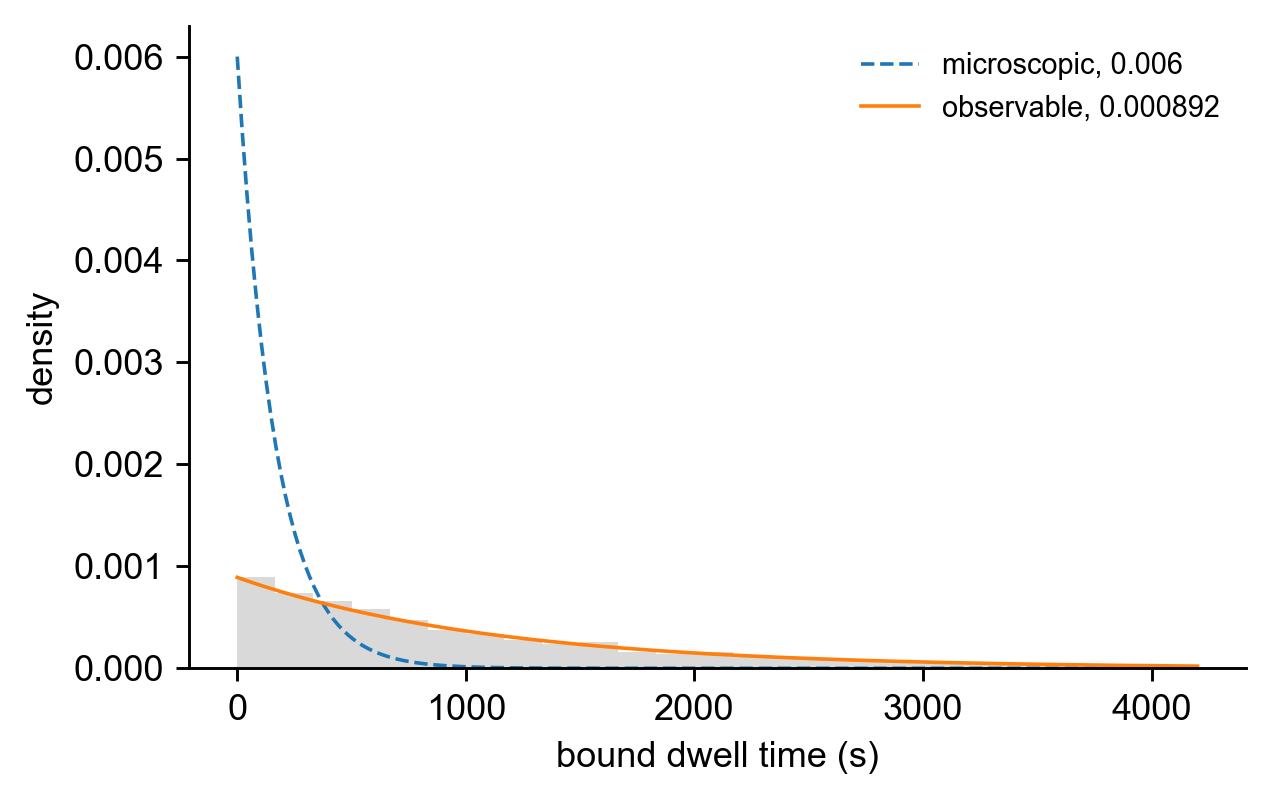

In [17]:
trace = sr.simulate(osym, {"searching": 200}, 20000.0, seed=0)
bound = trace.dwells("bound", until="searching")
rates = sr.dwell_rates(osym, "bound", "searching")

print(f"{len(trace)} jumps, {len(bound)} completed dwells")
print(f"mean dwell     {bound.mean():7.0f} s")
print(
    f"1 / k_d        {1 / rates['observable']:7.0f} s"
    f"   (passage_rates above: {1 / observed[1]:.0f} s)"
)
print(
    f"1 / k_off,mu   {1 / rates['microscopic']:7.0f} s"
    f"   (the graph's own rate: {1 / MICRO_OFF['Osym']:.0f} s)"
)

fig, ax = plt.subplots()
sr.dwell_diagram(
    osym, bound, "bound", "searching", bins=np.linspace(0, 4000, 25), ax=ax
)
ax.set_xlabel("bound dwell time (s)")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
save(fig, "dwells")

Averaged over molecules, the simulation and the master equation agree.

wrote figures/aggregate.pdf


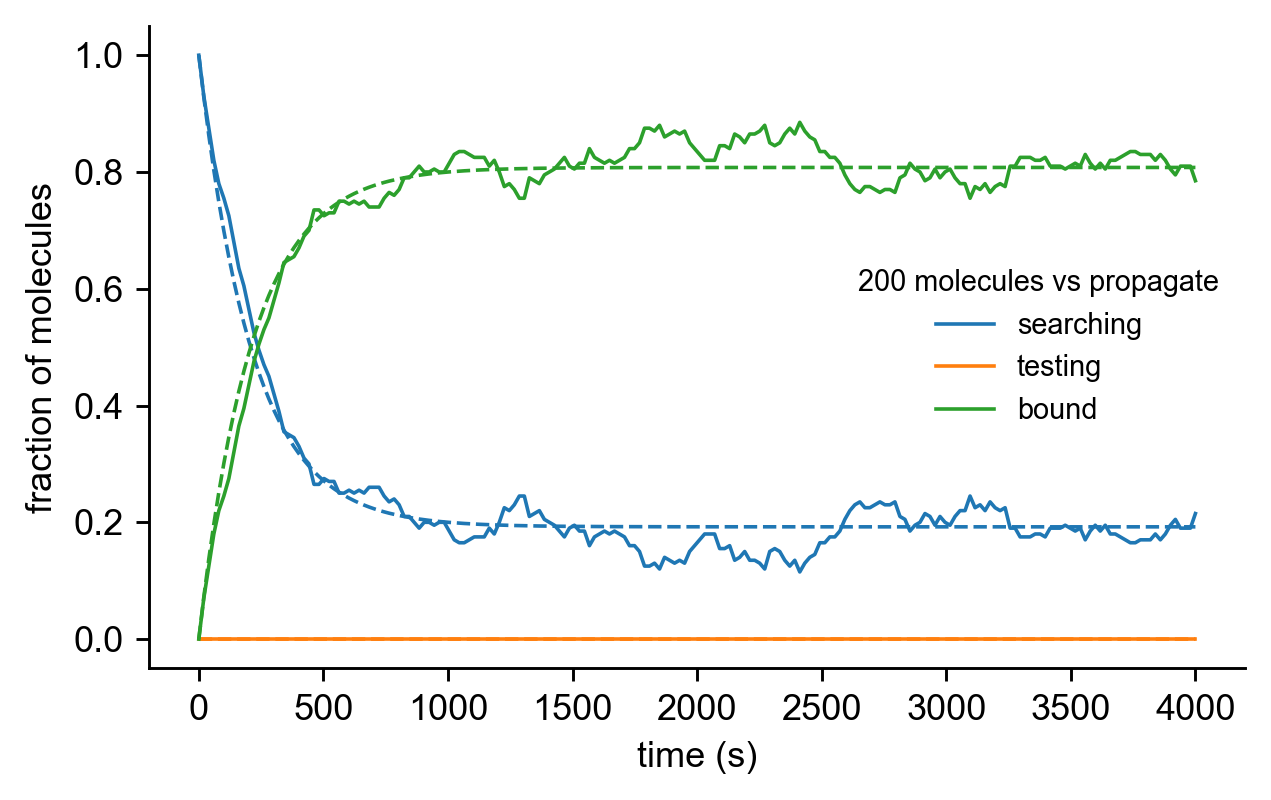

In [18]:
times = np.linspace(0, 4000, 200)
occupancy = trace.occupancy(times) / len(trace.initial)
expected = sr.propagate(osym, {"searching": 1.0}, times)

fig, ax = plt.subplots()
for state, index in zip(osym.states, (SEARCHING, TESTING, BOUND)):
    (drawn,) = ax.plot(times, occupancy[:, index], lw=1, label=state)
    ax.plot(times, expected[:, index], "--", color=drawn.get_color(), lw=1)
ax.set(xlabel="time (s)", ylabel="fraction of molecules")
ax.legend(
    frameon=False,
    fontsize=8,
    title="200 molecules vs propagate",
    title_fontsize=8,
)
fig.tight_layout()
save(fig, "aggregate")

## 11. Washout experiments

Taking the protein out of solution leaves a graph with no way back from
the free state, which is what an off-rate measurement is. Every
operator starts fully bound and the bound fraction decays — the
dissociation curves of Fig. 2B. Each one is a single exponential at its
own $k_\mathrm{d}$, and their half-lives span fivefold although the
barrier each repressor crosses on its way out of the well is the same
height, as §6 laid out. Read as a microscopic rate, every curve would
instead have to sit on the grey line.

              k_d  half-life  single exponential to


Osym    8.916e-04       777 s                7.5e-06
O1      2.796e-03       248 s                1.5e-05
O2      4.664e-03       149 s                1.8e-05
shared  6.000e-03       116 s   (microscopic)


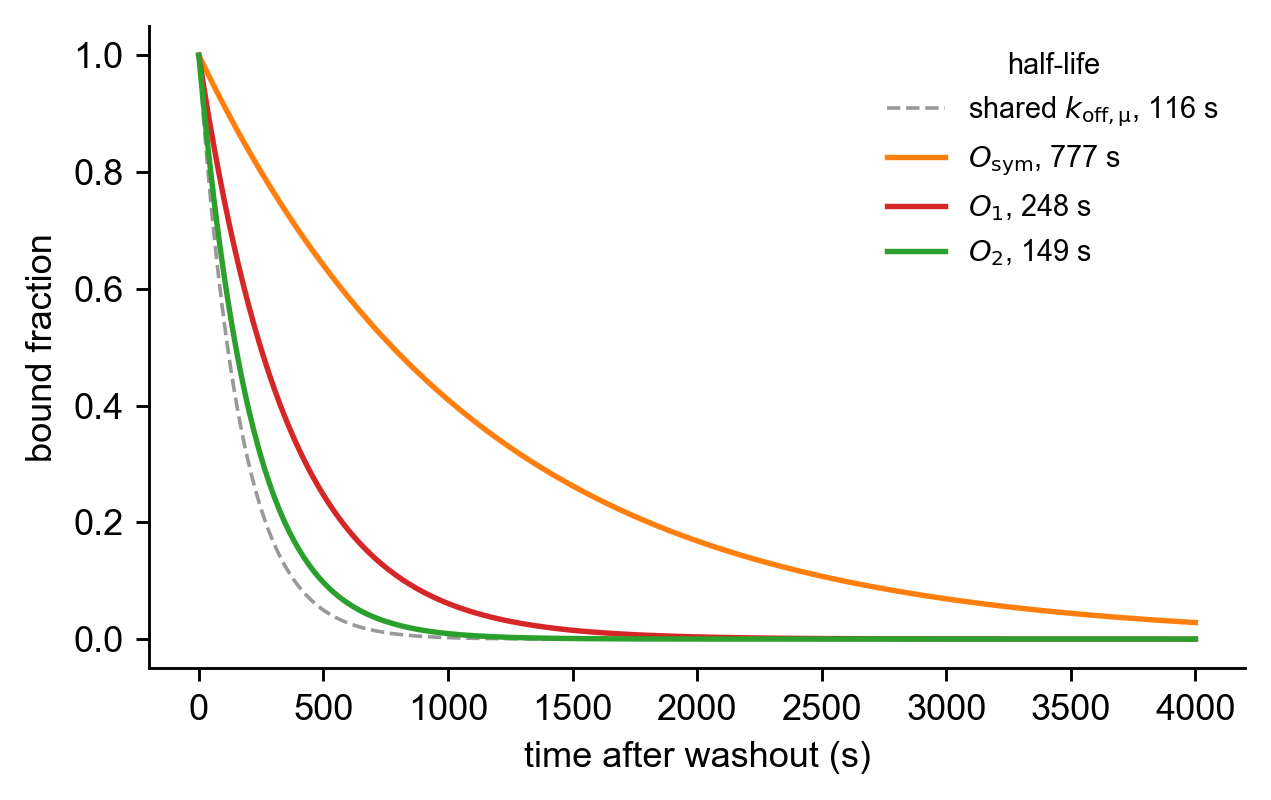

In [19]:
times = np.linspace(0, 4000, 400)

fig, ax = plt.subplots()
shared = MICRO_OFF["Osym"]
ax.plot(
    times,
    np.exp(-shared * times),
    color="0.6",
    ls="--",
    lw=1,
    label=rf"shared $k_\mathrm{{off,\mu}}$, {np.log(2) / shared:.0f} s",
)
print(f"{'':6} {'k_d':>10} {'half-life':>10} {'single exponential to':>22}")
for name, each in operators.items():
    washed = each.with_log_rates(
        each.log_rates.at[SEARCHING, TESTING].set(-jnp.inf)
    )
    decay = np.asarray(sr.propagate(washed, {"bound": 1.0}, times)[:, BOUND])
    k_d = float(macroscopic(each)[1])
    ax.plot(
        times,
        decay,
        color=COLOR[name],
        label=rf"{LABEL[name]}, {np.log(2) / k_d:.0f} s",
    )
    print(
        f"{name:6} {k_d:10.3e} {np.log(2) / k_d:9.0f} s"
        f" {np.abs(decay - np.exp(-k_d * times)).max():22.1e}"
    )
print(
    f"{'shared':6} {MICRO_OFF['Osym']:10.3e}"
    f" {np.log(2) / MICRO_OFF['Osym']:9.0f} s   (microscopic)"
)

ax.set(xlabel="time after washout (s)", ylabel="bound fraction")
ax.legend(frameon=False, fontsize=8, title="half-life", title_fontsize=8)
fig.tight_layout()

Individual molecules make the same point without any averaging. Twelve
of them, released from the bound state at the moment of the washout:
each trace dips to the testing state whenever the repressor crosses the
barrier out of the well, climbs back if it is recaptured, and flattens
along the bottom once it reaches solution, from where nothing brings it
back. The strong operator recaptures its repressor about six times
before losing it and the weak one rarely more than once, and that is
the whole of the difference between their dissociation rates. The
counts printed below come from 200 molecules rather than the twelve
drawn.

Osym  recaptures before escape   6.6, against 1/(1 - p_tot) =   6.7
      mean escape time   1127 s, 1/k_d =   1122 s, 84% of them within 2000 s


O2    recaptures before escape   1.2, against 1/(1 - p_tot) =   1.3
      mean escape time    219 s, 1/k_d =    214 s, 100% of them within 2000 s


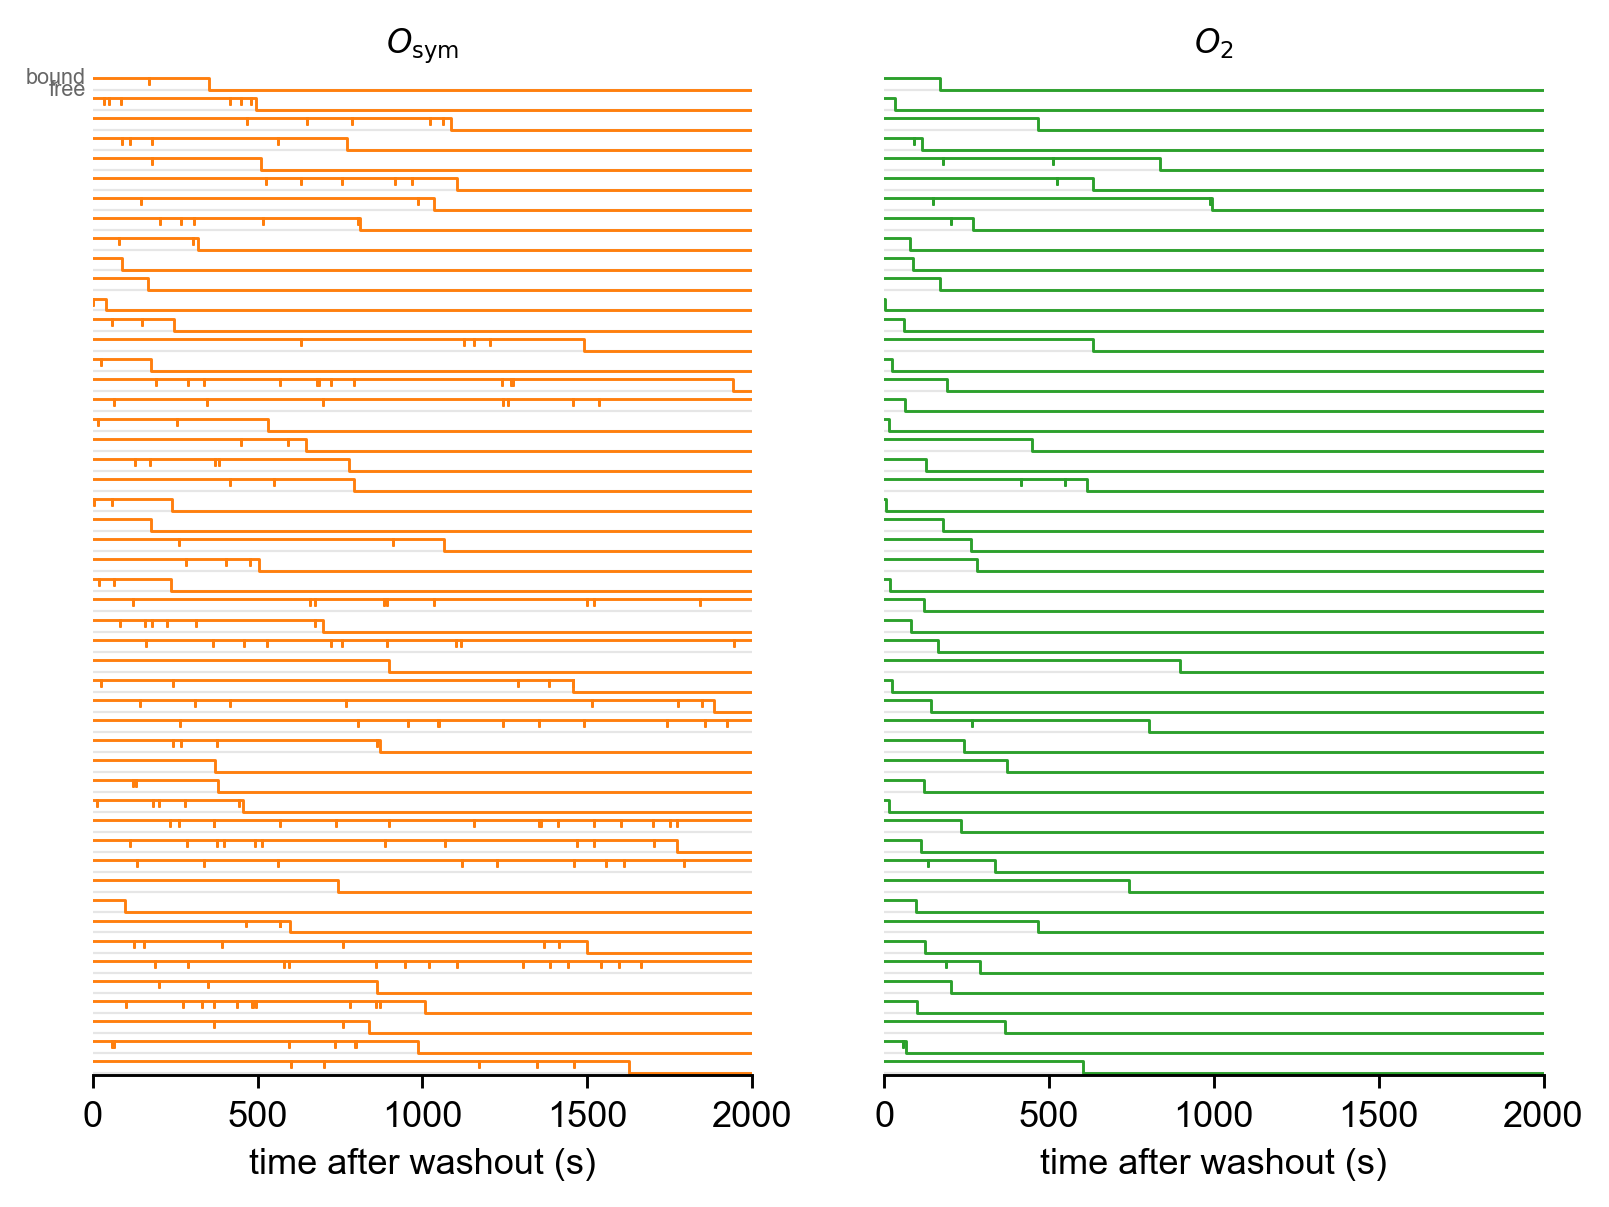

In [20]:
WINDOW, ROWS, MOLECULES = 2000.0, 50, 200

fig, axes = plt.subplots(ROWS, 2, figsize=(7.2, 5.0), sharex=True, sharey=True)
for column, name in zip(axes.T, ("Osym", "O2")):
    each = operators[name]
    washed = each.with_log_rates(
        each.log_rates.at[SEARCHING, TESTING].set(-jnp.inf)
    )
    trace = sr.simulate(washed, {"bound": MOLECULES}, 10 * WINDOW, seed=7)
    attempts, escapes = [], []
    for molecule in range(MOLECULES):
        when, visited = trace.path(molecule)
        attempts.append(int((visited == TESTING).sum()))
        reached = np.flatnonzero(visited == SEARCHING)
        if reached.size:
            escapes.append(when[reached[0]])
        if molecule >= ROWS:
            continue
        ax = column[molecule]
        ax.axhline(0, color="0.9", lw=0.6)
        inside = when <= WINDOW
        ax.step(
            np.append(when[inside], WINDOW),
            np.append(visited[inside], visited[inside][-1]),
            where="post",
            color=COLOR[name],
            lw=0.8,
        )
        ax.set(xlim=(0, WINDOW), ylim=(-0.4, 2.6), yticks=())
        ax.tick_params(left=False, bottom=False)
        for side in ("left", "bottom"):
            ax.spines[side].set_visible(False)
    column[0].set_title(LABEL[name], fontsize=9)
    p_tot = recognition_probability(each)
    print(
        f"{name:5} recaptures before escape {np.mean(attempts):5.1f},"
        f" against 1/(1 - p_tot) = {1 / (1 - p_tot):5.1f}"
    )
    print(
        f"{'':5} mean escape time {np.mean(escapes):6.0f} s,"
        f" 1/k_d = {1 / float(macroscopic(each)[1]):6.0f} s,"
        f" {np.mean(np.asarray(escapes) <= WINDOW):.0%} of them"
        f" within {WINDOW:.0f} s"
    )

for level, label in ((2, "bound"), (0, "free")):
    axes[0, 0].text(
        -0.01,
        (level + 0.4) / 3.0,
        label,
        fontsize=6,
        color="0.4",
        ha="right",
        va="center",
        transform=axes[0, 0].transAxes,
    )
for ax in axes[-1]:
    ax.set_xlabel("time after washout (s)")
    ax.spines["bottom"].set_visible(True)
    ax.tick_params(bottom=True)
fig.subplots_adjust(hspace=0.12)

## 12. Fitting microscopic rates to measured macroscopic ones

The paper's use of Eq. 1 is an inverse problem: given a measured
$(k_\mathrm{a}, k_\mathrm{d})$ and a known $k_\mathrm{on,max}$, solve
for $p_\mathrm{tot}$ and $k_\mathrm{off,\mu}$. A graph is a JAX pytree,
so the reduction in §5 is differentiable and the same problem can be
posed for any model, with or without a closed form. Here
Levenberg–Marquardt recovers the microscopic rates of all four operators
from their macroscopic pair.

In [21]:
def residual(parameters, target):
    """Log-residual of the macroscopic rates in k_on,mu and k_off,mu."""
    rates = (
        osym.log_rates.at[TESTING, BOUND]
        .set(parameters[0])
        .at[BOUND, TESTING]
        .set(parameters[1])
    )
    return jnp.log(macroscopic(osym.with_log_rates(rates))) - jnp.log(target)


solver = optx.LevenbergMarquardt(rtol=1e-10, atol=1e-12)
guess = jnp.array([np.log(1.0), np.log(1e-1)])
print(
    f"{'':5} {'k_on,mu':>9} {'k_off,mu':>10} {'p_tot':>7}"
    f" {'true k_on,mu':>13} {'true k_off,mu':>14}"
)
for name, each in operators.items():
    fit = optx.least_squares(residual, solver, guess, args=macroscopic(each))
    # The fitted parameters are log rates, so they make an ordinary graph
    fitted = osym.with_log_rates(
        osym.log_rates.at[TESTING, BOUND]
        .set(fit.value[0])
        .at[BOUND, TESTING]
        .set(fit.value[1])
    )
    print(
        f"{name:5} {float(fitted.rates[TESTING, BOUND]):9.2f}"
        f" {float(fitted.rates[BOUND, TESTING]):10.5f}"
        f" {recognition_probability(fitted):7.3f}"
        f" {float(each.rates[TESTING, BOUND]):13.2f}"
        f" {float(each.rates[BOUND, TESTING]):14.5f}"
    )

        k_on,mu   k_off,mu   p_tot  true k_on,mu  true k_off,mu


Osym     572.96    0.00600   0.851        572.96        0.00600
O1       114.59    0.00600   0.534        114.59        0.00600
O2        28.65    0.00600   0.223         28.65        0.00600


## Reusing this

The pattern generalizes. Write the mechanism down once as a `Scheme` and
instantiate it per variant — or build a `Graph` directly if there is only
one set of rates — express perturbations as `Mutation` objects in kcal/mol, decide
which states the experiment cannot separate and reduce with
`passage_rates` for dwell times or `coarse_grain` for equilibrium
fluxes, then use `propagate`, `integrate` or `simulate` for whichever
observable the instrument records — `Trajectory.dwells` with
`dwell_rates` if that observable is a dwell time. Because every graph is a JAX pytree,
the whole chain is differentiable, so it can be fitted to data or swept
over a library of variants in one batch.